# Lab 3: Obtain and Equalize Histogram

## 1. Program to obtain histogram

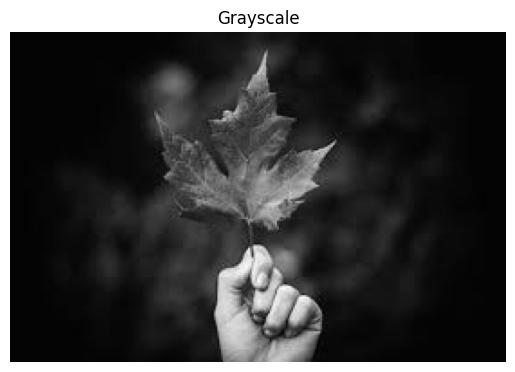

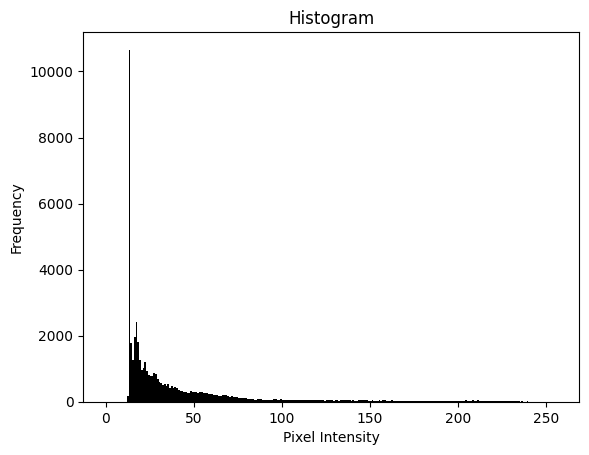

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read the image
I = cv2.imread('./img/red-leaf.jpg')

# Convert the image to grayscale
J = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.figure()
plt.imshow(J, cmap='gray')
plt.title('Grayscale')
plt.axis('off') # Hide axis
plt.show()

# Display the histogram
plt.figure()
plt.hist(J.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

## 2. Program to perform histogram equalization

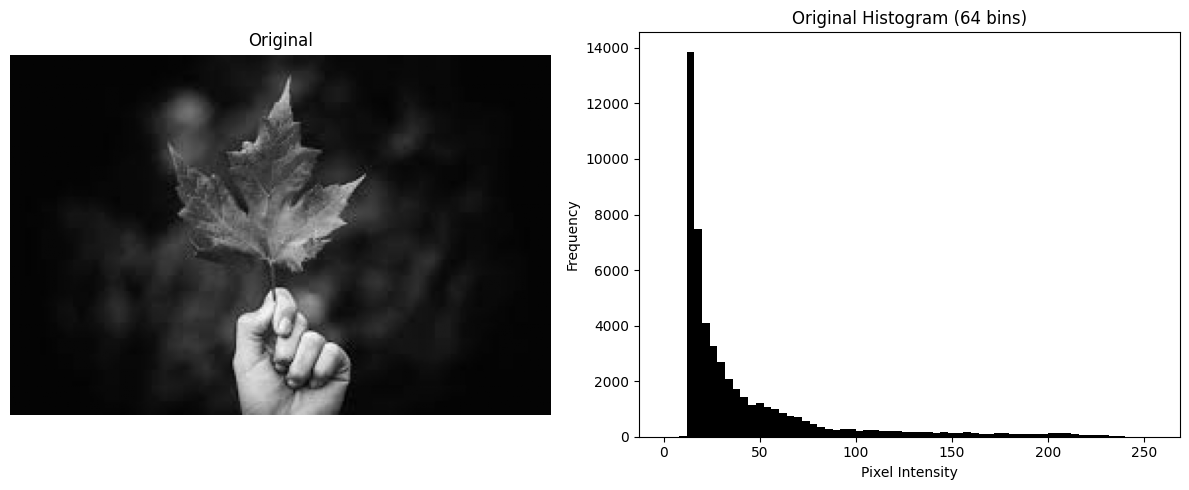

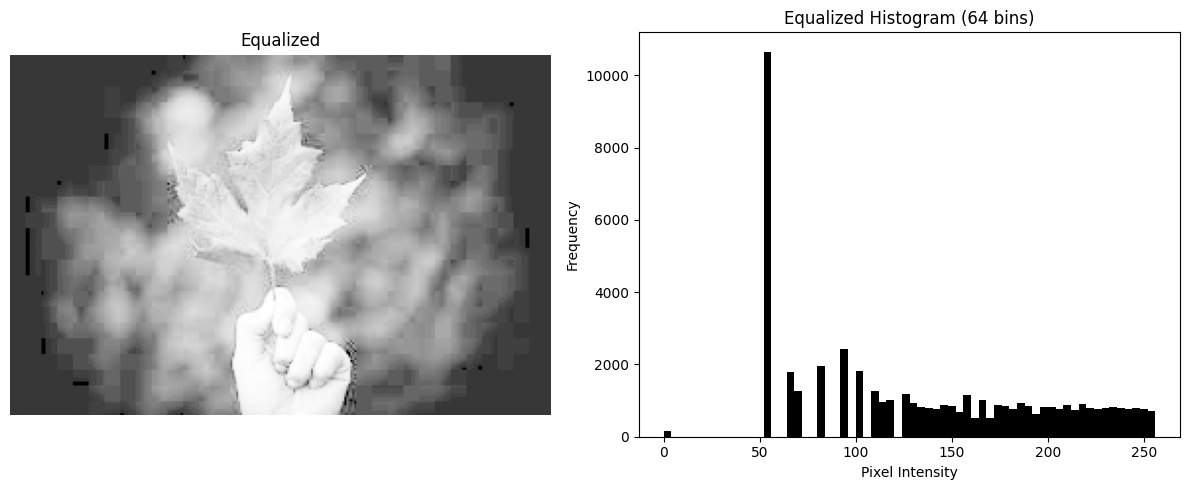

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to compute histogram and CDF for grayscale image
def compute_hist_cdf(image, bins=256):
    hist, bin_edges = np.histogram(image.flatten(), bins=bins, range=[0,bins])
    cdf = hist.cumsum()
    # Normalize cdf
    cdf_normalized = cdf / cdf[-1]
    return hist, cdf_normalized

# Read the image
A = cv2.imread('./img/red-leaf.jpg')

# Convert to grayscale
I = cv2.cvtColor(A, cv2.COLOR_BGR2GRAY)

# Display original grayscale image and histogram (64 bins)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(I, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.hist(I.ravel(), bins=64, range=[0,256], color='black')
plt.title('Original Histogram (64 bins)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Histogram equalization
J = cv2.equalizeHist(I)
# Display equalized image and histogram (64 bins)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(J, cmap='gray')
plt.title('Equalized')
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(J.ravel(), bins=64, range=[0,256], color='black')
plt.title('Equalized Histogram (64 bins)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. area of circle using function

In [3]:
import math
# Function to compute area of a circle
def circle_area(radius):
    """Compute the area of a circle with given radius."""
    if radius < 0:
        return "Radius cannot be negative."
    return math.pi * radius ** 2

# Test the function
r = 5 # example radius
area = circle_area(r)
print(f"The area of a circle with radius {r} is: {area:.2f}")

r=6
area = circle_area(r)
print(f"The area of a circle with radius {r} is: {area:.2f}")

The area of a circle with radius 5 is: 78.54
The area of a circle with radius 6 is: 113.10


## Image Filtering Mask Demo

IMAGE PROCESSING FILTERING MASKS DEMONSTRATION

Loading sample image...
Image shape: (512, 512)
Image data type: uint8

Loaded 12 different filter masks/kernels

1. VISUALIZING ALL FILTERS...


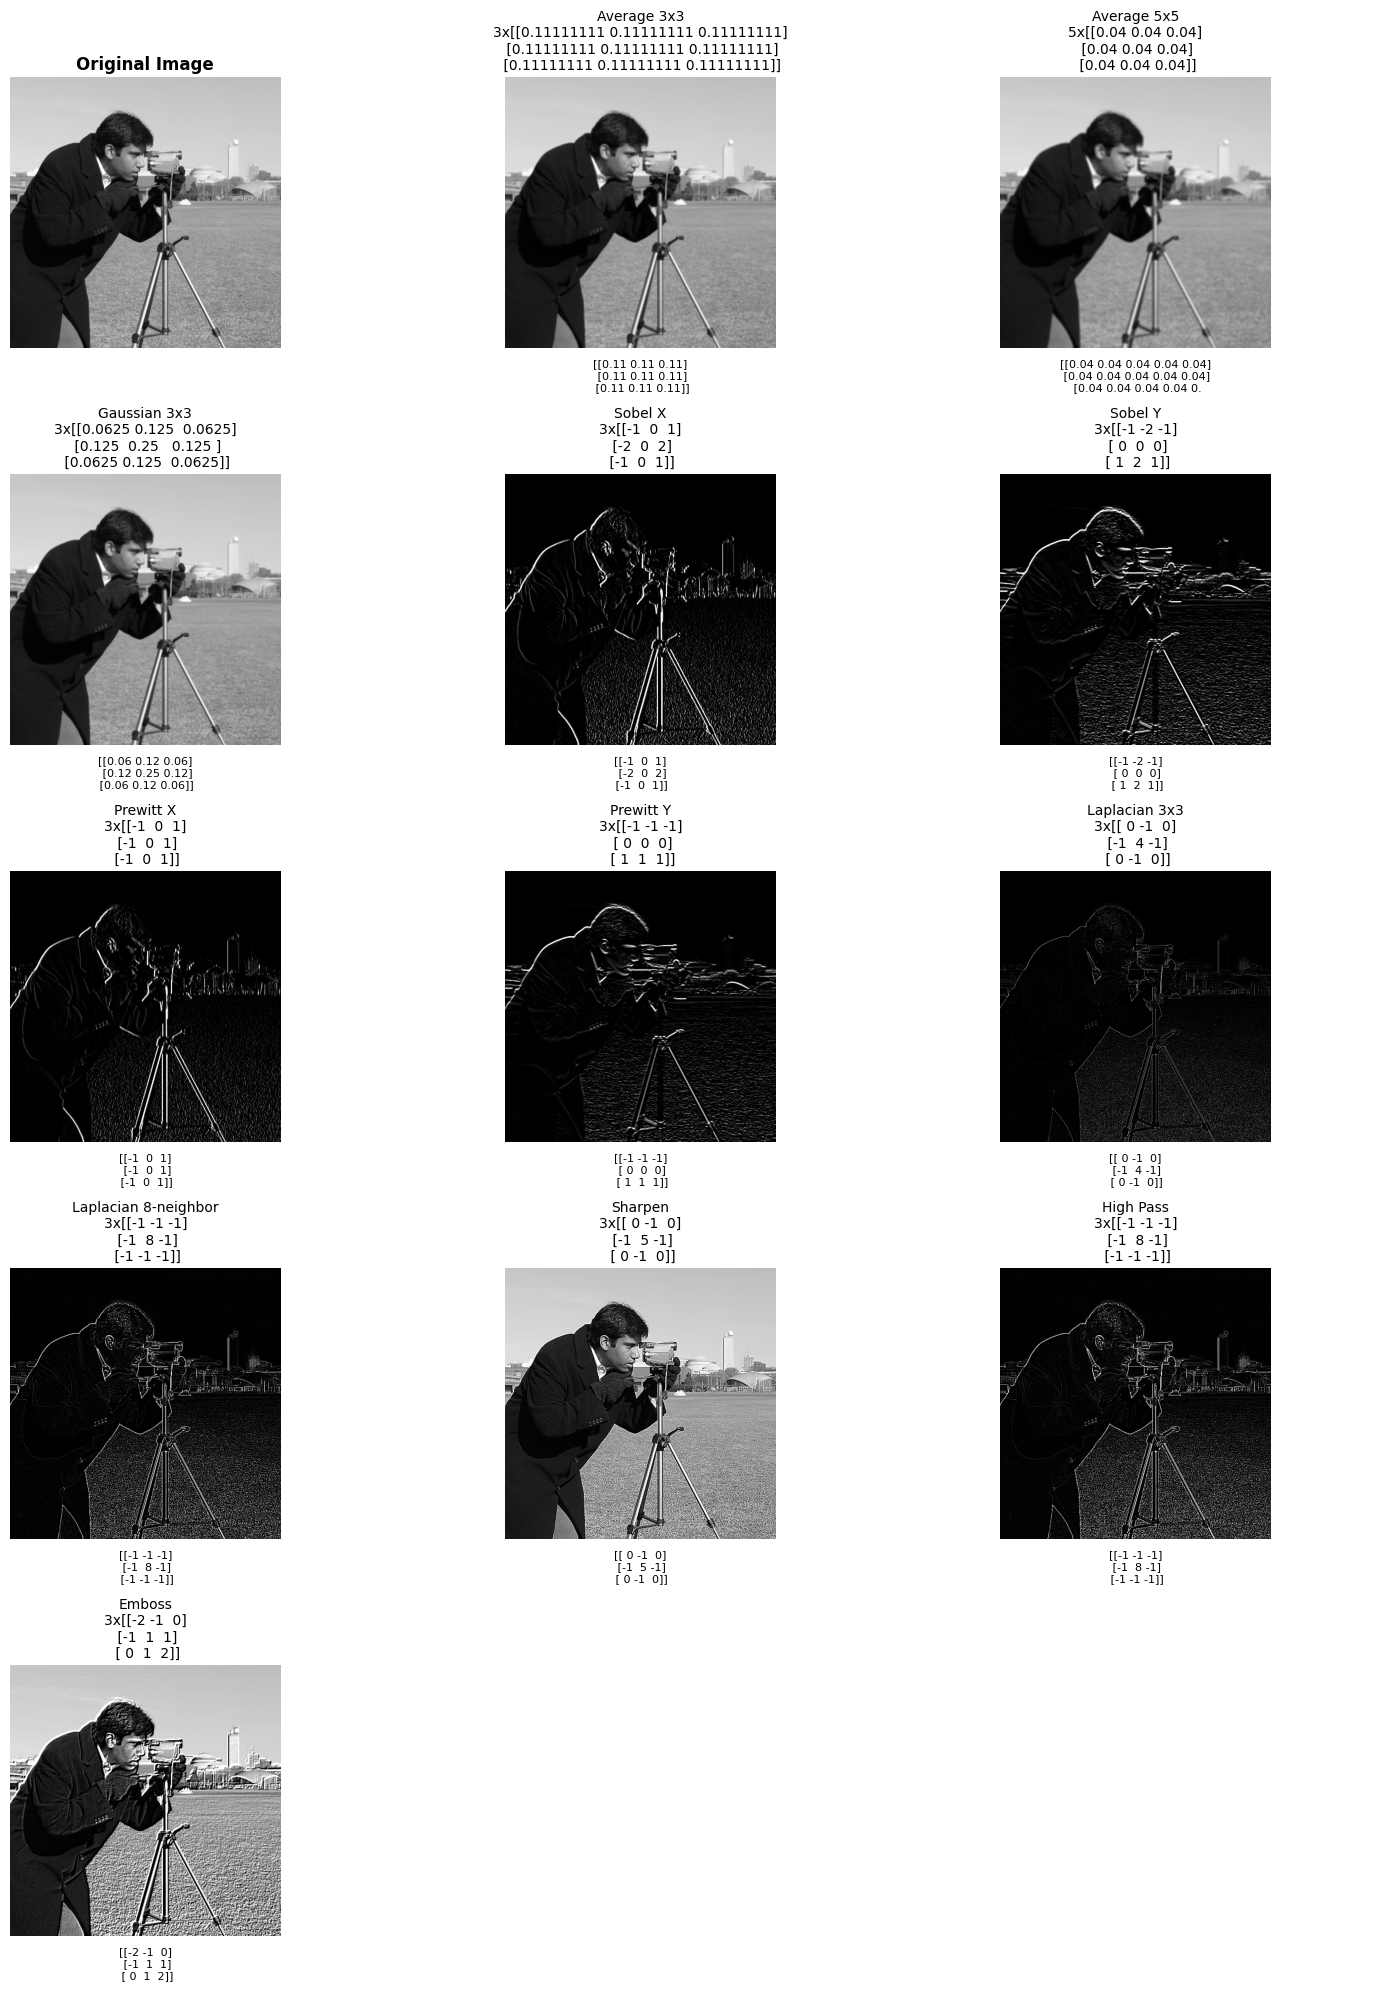


2. KERNEL VISUALIZATION (Test Pattern)...


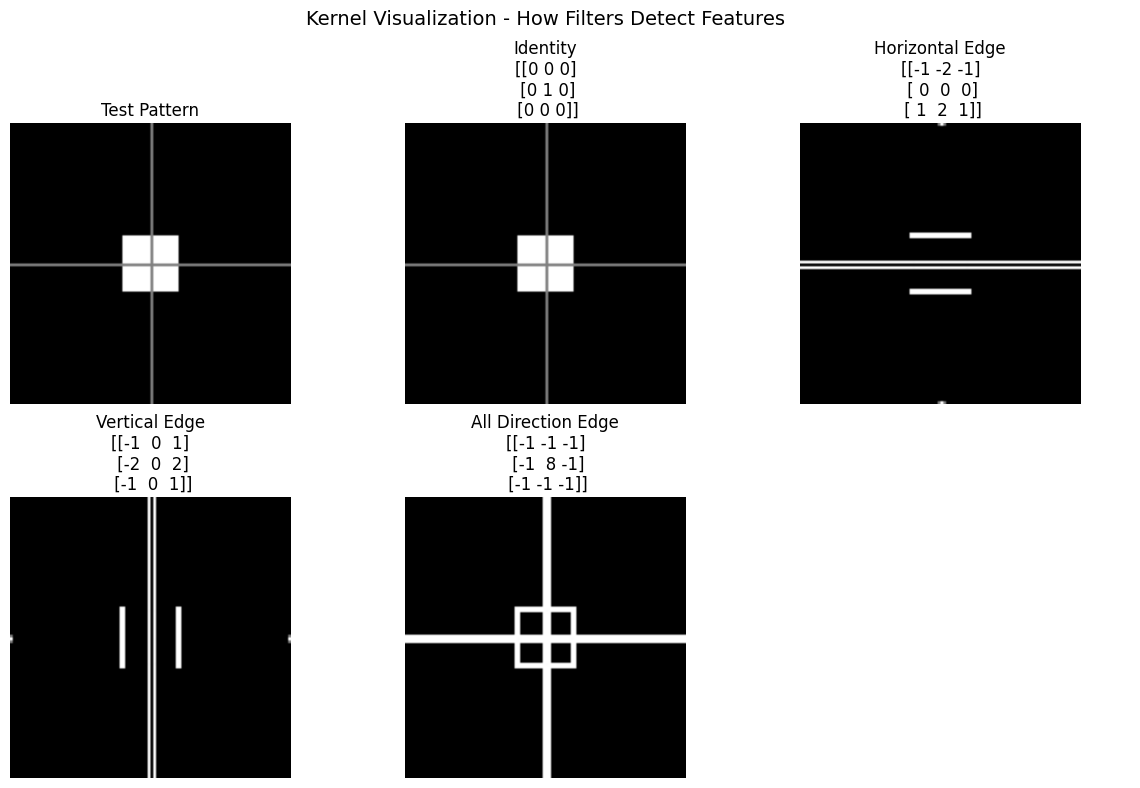


3. COMPARING FILTER TYPES...


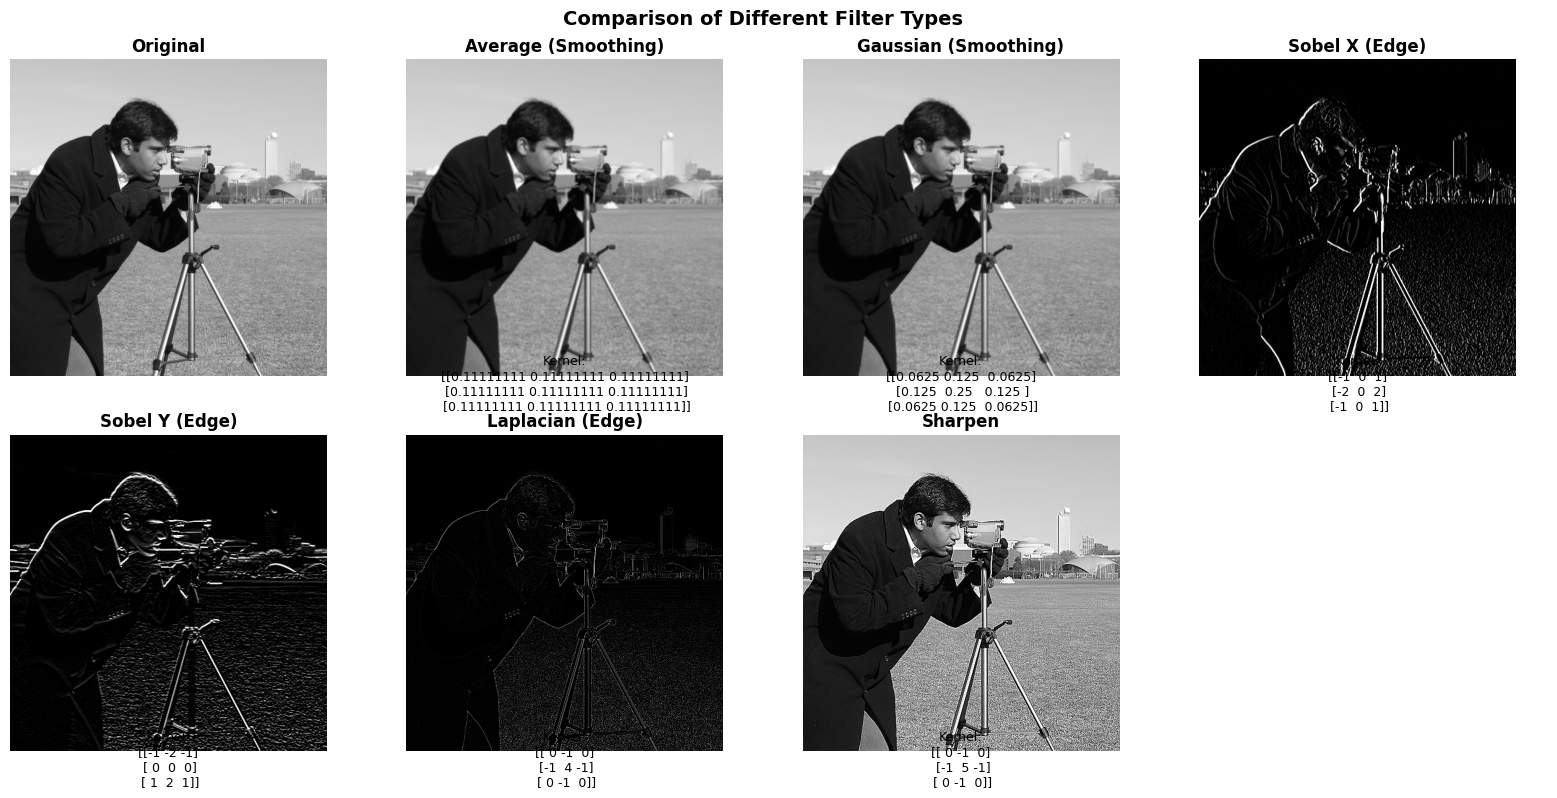


4. INTERACTIVE DEMO MODE...

INTERACTIVE FILTER DEMO

Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit


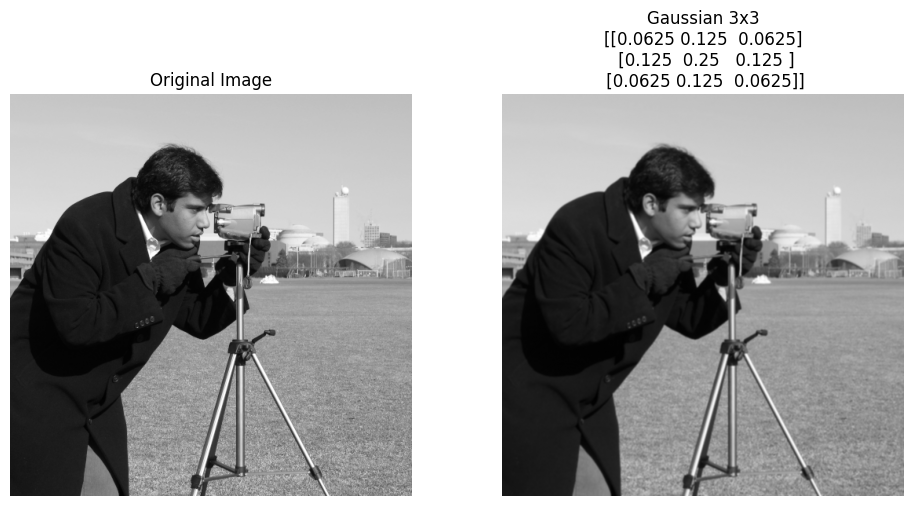


Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit
Invalid input. Please try again.

Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit
Invalid input. Please try again.

Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit
Invalid input. Please try again.

Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit
Invalid input. Please try aga

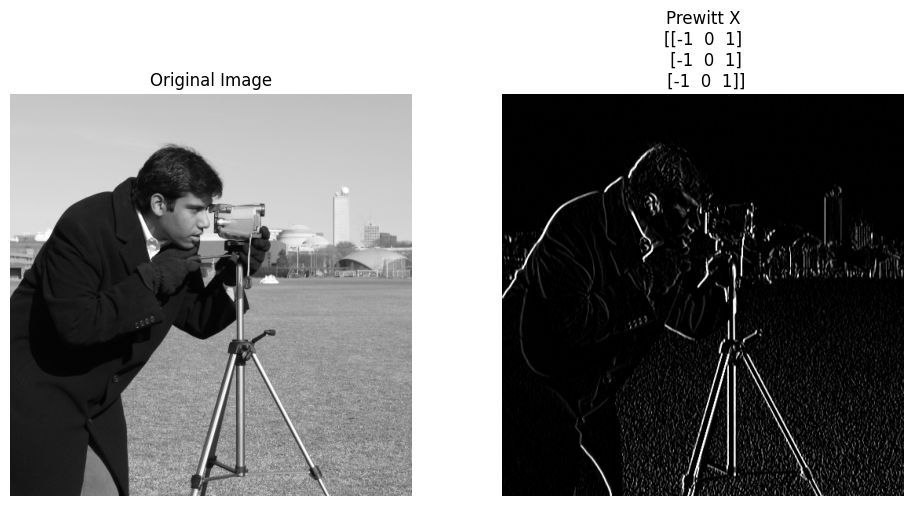


Available filters:
1. Average 3x3
2. Average 5x5
3. Gaussian 3x3
4. Sobel X
5. Sobel Y
6. Prewitt X
7. Prewitt Y
8. Laplacian 3x3
9. Laplacian 8-neighbor
10. Sharpen
11. High Pass
12. Emboss
13. Custom filter
0. Exit
Exiting interactive demo...

DEMONSTRATION COMPLETE!

SUMMARY:
----------------------------------------
Filter Types Demonstrated:
  • Smoothing (Low-pass): Average, Gaussian
  • Edge Detection (High-pass): Sobel, Prewitt, Laplacian
  • Sharpening: High-pass, Sharpen
  • Artistic: Emboss

Key Concepts:
  • Convolution: Kernel slides over image
  • Kernel size: Affects filter response
  • Kernel values: Determine filter behavior
  • Boundary handling: Symmetric padding used


In [3]:
# Image Filtering Masks Demo in Google Colab
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from skimage import io, filters, color
import requests
from PIL import Image
import cv2

# Download a sample image or use built-in
def load_sample_image():
    """Load a sample image for filtering"""
    # Using a sample image from scikit-image
    from skimage import data
    image = data.camera()  # Built-in grayscale image
    return image

# Define different filtering masks (kernels)
def get_filter_masks():
    """Define various filtering masks/kernels"""

    masks = {
        # Smoothing filters (low-pass)
        'Average 3x3': np.ones((3,3)) / 9,
        'Average 5x5': np.ones((5,5)) / 25,
        'Gaussian 3x3': (1/16) * np.array([
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1]
        ]),

        # Edge detection filters (high-pass)
        'Sobel X': np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ]),
        'Sobel Y': np.array([
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]
        ]),
        'Prewitt X': np.array([
            [-1, 0, 1],
            [-1, 0, 1],
            [-1, 0, 1]
        ]),
        'Prewitt Y': np.array([
            [-1, -1, -1],
            [0, 0, 0],
            [1, 1, 1]
        ]),

        # Laplacian (edge detection)
        'Laplacian 3x3': np.array([
            [0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0]
        ]),
        'Laplacian 8-neighbor': np.array([
            [-1, -1, -1],
            [-1, 8, -1],
            [-1, -1, -1]
        ]),

        # Sharpening filters
        'Sharpen': np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ]),
        'High Pass': np.array([
            [-1, -1, -1],
            [-1, 8, -1],
            [-1, -1, -1]
        ]),

        # Emboss filter
        'Emboss': np.array([
            [-2, -1, 0],
            [-1, 1, 1],
            [0, 1, 2]
        ])
    }

    return masks

def apply_filter(image, kernel):
    """Apply a filtering mask to the image"""
    # Use scipy signal's convolve2d
    filtered = signal.convolve2d(image, kernel, mode='same', boundary='symm')

    # Clip values to valid range [0, 255]
    filtered = np.clip(filtered, 0, 255).astype(np.uint8)

    return filtered

def visualize_filters(original_image, masks):
    """Visualize original image and all filtered results"""

    num_masks = len(masks)
    # Calculate grid size (3 columns, enough rows for all masks)
    n_cols = 3
    n_rows = (num_masks + 1 + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    # Show original image
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Apply and show each filter
    for idx, (name, kernel) in enumerate(masks.items(), start=1):
        filtered = apply_filter(original_image, kernel)

        axes[idx].imshow(filtered, cmap='gray')
        axes[idx].set_title(f'{name}\n{kernel.shape[0]}x{kernel[0:3,0:3]}',
                           fontsize=10)
        axes[idx].axis('off')

        # Add kernel text below some images
        if idx < len(axes):
            kernel_text = np.array2string(kernel, precision=2, suppress_small=True, max_line_width=30)
            axes[idx].text(0.5, -0.15, kernel_text[:80],
                          transform=axes[idx].transAxes,
                          fontsize=8, ha='center', wrap=True)

    # Hide any unused subplots
    for idx in range(len(masks) + 1, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

def interactive_filter_demo(original_image, masks):
    """Interactive demo to try custom filters"""
    print("\n" + "="*60)
    print("INTERACTIVE FILTER DEMO")
    print("="*60)

    while True:
        print("\nAvailable filters:")
        mask_list = list(masks.keys())
        for i, name in enumerate(mask_list, 1):
            print(f"{i}. {name}")
        print(f"{len(mask_list)+1}. Custom filter")
        print("0. Exit")

        try:
            choice = int(input("\nSelect a filter (0-{}): ".format(len(mask_list)+1)))

            if choice == 0:
                print("Exiting interactive demo...")
                break
            elif choice == len(mask_list) + 1:
                # Custom filter
                print("\nEnter custom 3x3 kernel values (space-separated rows):")
                kernel = []
                for i in range(3):
                    row = list(map(float, input(f"Row {i+1}: ").split()))
                    if len(row) != 3:
                        print("Please enter exactly 3 numbers")
                        return
                    kernel.append(row)
                kernel = np.array(kernel)
                filter_name = "Custom Filter"
            else:
                filter_name = mask_list[choice-1]
                kernel = masks[filter_name]

            # Apply and display
            filtered = apply_filter(original_image, kernel)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            ax1.imshow(original_image, cmap='gray')
            ax1.set_title('Original Image')
            ax1.axis('off')

            ax2.imshow(filtered, cmap='gray')
            ax2.set_title(f'{filter_name}\n{kernel}')
            ax2.axis('off')

            plt.tight_layout()
            plt.show()

        except ValueError:
            print("Invalid input. Please try again.")
        except Exception as e:
            print(f"Error: {e}")

def compare_filters(original_image, masks):
    """Compare specific filter types"""

    # Select filters for comparison
    filters_to_compare = {
        'Original': None,
        'Average (Smoothing)': masks['Average 3x3'],
        'Gaussian (Smoothing)': masks['Gaussian 3x3'],
        'Sobel X (Edge)': masks['Sobel X'],
        'Sobel Y (Edge)': masks['Sobel Y'],
        'Laplacian (Edge)': masks['Laplacian 3x3'],
        'Sharpen': masks['Sharpen']
    }

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, (name, kernel) in enumerate(filters_to_compare.items()):
        if kernel is None:
            result = original_image
        else:
            result = apply_filter(original_image, kernel)

        axes[idx].imshow(result, cmap='gray')
        axes[idx].set_title(name, fontsize=12, fontweight='bold')
        axes[idx].axis('off')

        if kernel is not None:
            axes[idx].text(0.5, -0.1, f'Kernel:\n{kernel}',
                          transform=axes[idx].transAxes,
                          fontsize=9, ha='center', wrap=True)

    # Hide the last subplot if not needed
    if len(filters_to_compare) < len(axes):
        axes[-1].axis('off')

    plt.suptitle('Comparison of Different Filter Types', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_kernel_visualization():
    """Visualize how kernels work"""

    # Create a simple test pattern
    test_pattern = np.zeros((100, 100))
    test_pattern[40:60, 40:60] = 255  # White square
    test_pattern[50, :] = 128  # Horizontal line
    test_pattern[:, 50] = 128  # Vertical line

    # Apply different kernels to show their effect
    kernels = {
        'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
        'Horizontal Edge': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
        'Vertical Edge': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
        'All Direction Edge': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    }

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    # Original pattern
    axes[0].imshow(test_pattern, cmap='gray')
    axes[0].set_title('Test Pattern')
    axes[0].axis('off')

    # Show kernel effects
    for idx, (name, kernel) in enumerate(kernels.items(), 1):
        result = signal.convolve2d(test_pattern, kernel, mode='same')
        result = np.clip(np.abs(result), 0, 255).astype(np.uint8)

        axes[idx].imshow(result, cmap='gray')
        axes[idx].set_title(f'{name}\n{kernel}')
        axes[idx].axis('off')

    axes[5].axis('off')
    plt.suptitle('Kernel Visualization - How Filters Detect Features', fontsize=14)
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    print("="*60)
    print("IMAGE PROCESSING FILTERING MASKS DEMONSTRATION")
    print("="*60)

    # Load image
    print("\nLoading sample image...")
    image = load_sample_image()
    print(f"Image shape: {image.shape}")
    print(f"Image data type: {image.dtype}")

    # Get filter masks
    masks = get_filter_masks()
    print(f"\nLoaded {len(masks)} different filter masks/kernels")

    # 1. Basic visualization of all filters
    print("\n1. VISUALIZING ALL FILTERS...")
    visualize_filters(image, masks)

    # 2. Kernel visualization (how they work)
    print("\n2. KERNEL VISUALIZATION (Test Pattern)...")
    show_kernel_visualization()

    # 3. Compare specific filter types
    print("\n3. COMPARING FILTER TYPES...")
    compare_filters(image, masks)

    # 4. Interactive demo
    print("\n4. INTERACTIVE DEMO MODE...")
    interactive_filter_demo(image, masks)

    print("\n" + "="*60)
    print("DEMONSTRATION COMPLETE!")
    print("="*60)

    # Display summary information
    print("\nSUMMARY:")
    print("-"*40)
    print("Filter Types Demonstrated:")
    print("  • Smoothing (Low-pass): Average, Gaussian")
    print("  • Edge Detection (High-pass): Sobel, Prewitt, Laplacian")
    print("  • Sharpening: High-pass, Sharpen")
    print("  • Artistic: Emboss")
    print("\nKey Concepts:")
    print("  • Convolution: Kernel slides over image")
    print("  • Kernel size: Affects filter response")
    print("  • Kernel values: Determine filter behavior")
    print("  • Boundary handling: Symmetric padding used")